### Comparing Aggregate Models for Regression

This try-it focuses on utilizing ensemble models in a regression setting.  Much like you have used individual classification estimators to form an ensemble of estimators -- here your goal is to explore ensembles for regression models.  As with your earlier assignment, you will use scikitlearn to carry out the ensembles using the `VotingRegressor`.   


#### Dataset and Task

Below, a dataset containing census information on individuals and their hourly wage is loaded using the `fetch_openml` function.  OpenML is another repository for datasets [here](https://www.openml.org/).  Your task is to use ensemble methods to explore predicting the `wage` column of the data.  Your ensemble should at the very least consider the following models:

- `LinearRegression` -- perhaps you even want the `TransformedTargetRegressor` here.
- `KNeighborsRegressor`
- `DecisionTreeRegressor`
- `Ridge`
- `SVR`

Tune the `VotingRegressor` to try to optimize the prediction performance and determine if the wisdom of the crowd performed better in this setting than any of the individual models themselves.  Report back on your findings and discuss the interpretability of your findings.  Is there a way to determine what features mattered in predicting wages?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Load dataset
survey = fetch_openml(data_id=534, as_frame=True).frame

In [4]:
# Display the first few rows to understand the data
survey.head()

,EDUCATION,SOUTH,SEX,EXPERIENCE,UNION,WAGE,AGE,RACE,OCCUPATION,SECTOR,MARR
0,8,no,female,21,not_member,5.10,35,Hispanic,Other,Manufacturing,Married
1,9,no,female,42,not_member,4.95,57,White,Other,Manufacturing,Married
2,12,no,male,1,not_member,6.67,19,White,Other,Manufacturing,Unmarried
3,12,no,male,4,not_member,4.00,22,White,Other,Other,Unmarried
4,12,no,male,17,not_member,7.50,35,White,Other,Other,Married


In [5]:
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   EDUCATION   534 non-null    int64   
 1   SOUTH       534 non-null    category
 2   SEX         534 non-null    category
 3   EXPERIENCE  534 non-null    int64   
 4   UNION       534 non-null    category
 5   WAGE        534 non-null    float64 
 6   AGE         534 non-null    int64   
 7   RACE        534 non-null    category
 8   OCCUPATION  534 non-null    category
 9   SECTOR      534 non-null    category
 10  MARR        534 non-null    category
dtypes: category(7), float64(1), int64(3)
memory usage: 21.4 KB


In [6]:
survey['SOUTH'].value_counts()
survey['UNION'].value_counts()
survey['RACE'].value_counts()
survey['SECTOR'].value_counts()
survey['OCCUPATION'].value_counts()
#survey['MARR'].value_counts()

,count
OCCUPATION,
Other,156
Professional,105
Clerical,97
Service,83
Management,55
Sales,38


In [ ]:
### scale the WAGE
scalar = StandardScaler()
survey['WAGE'] = scalar.fit_transform(survey[['WAGE']])
X = survey.drop('WAGE', axis=1)
y = survey['WAGE']

In [ ]:
### One hot encoding for the columns
transformer = ColumnTransformer(transformers= [('onehot', OneHotEncoder(sparse_output=False), ['SOUTH', 'SEX', 'UNION', 'RACE', 'SECTOR', 'MARR', 'OCCUPATION'])
                                ], remainder='passthrough')

estimators = [('LinearRegression', LinearRegression()), ('KNeighborRegressor', KNeighborsRegressor()), ('DecisionTreeRegressor', DecisionTreeRegressor()), ('Ridge', Ridge()), ('SVR', SVR())]

voting_regressor = VotingRegressor(estimators=estimators)
all_regressors = estimators + [('VotingRegression', voting_regressor)]

def fit_all_regressors(all_regressors):
  results = dict()
  for est in all_regressors:
    name = est[0]
    model = est[1]
    print(model)
    pipe = Pipeline( [('transform', transformer), ('regressor', model)]).fit(X,y)
    results[name] = pipe.score(X,y)

  print(results)
  acc_df = pd.DataFrame({'Model Name': [key for key in results.keys()],
                        'Accuracy' : [val for val in results.values()]} )
  return acc_df
acc_df = fit_all_regressors(all_regressors)


LinearRegression()
KNeighborsRegressor()
DecisionTreeRegressor()
Ridge()
SVR()
VotingRegressor(estimators=[('LinearRegression', LinearRegression()),
                            ('KNeighborRegressor', KNeighborsRegressor()),
                            ('DecisionTreeRegressor', DecisionTreeRegressor()),
                            ('Ridge', Ridge()), ('SVR', SVR())])
{'LinearRegression': 0.32649082803385066, 'KNeighborRegressor': 0.4294569622092005, 'DecisionTreeRegressor': 0.968242774097533, 'Ridge': 0.3264656827442751, 'SVR': 0.20570834737027877, 'VotingRegression': 0.5888181880288859}


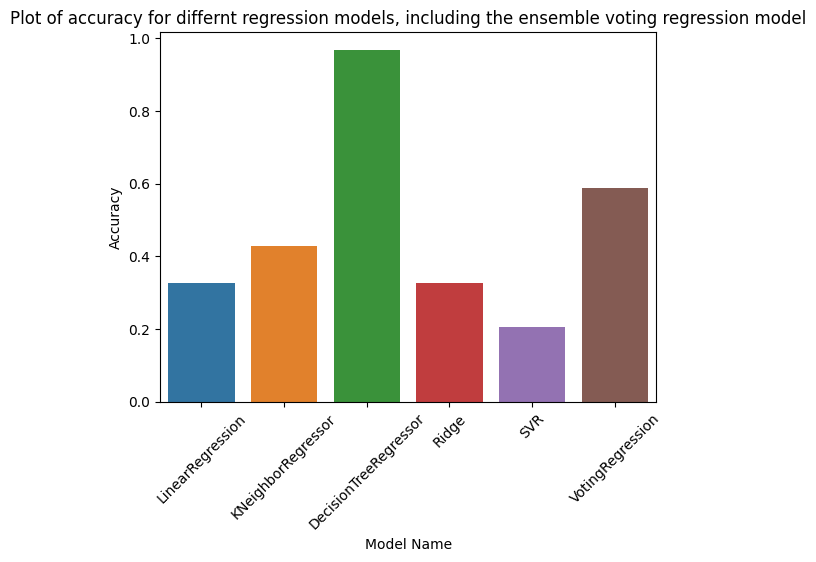

In [ ]:


import seaborn as sns
def plot_model_accuracy(acc_df, msg=''):
  sns.barplot(acc_df, x='Model Name', y='Accuracy', hue='Model Name')
  plt.xticks(rotation=45)
  plt.title('Plot of accuracy for differnt regression models, including the ensemble {}voting regression model'.format(msg))
  plt.show()
plot_model_accuracy(acc_df)

LinearRegression()
KNeighborsRegressor()
DecisionTreeRegressor()
Ridge()
SVR()
VotingRegressor(estimators=[('LinearRegression', LinearRegression()),
                            ('KNeighborRegressor', KNeighborsRegressor()),
                            ('DecisionTreeRegressor', DecisionTreeRegressor()),
                            ('Ridge', Ridge()), ('SVR', SVR())],
                weights=[0.1, 0.2, 0.4, 0.2, 0.1])
{'LinearRegression': 0.32649082803385066, 'KNeighborRegressor': 0.4294569622092005, 'DecisionTreeRegressor': 0.968242774097533, 'Ridge': 0.3264656827442751, 'SVR': 0.20570834737027877, 'VotingRegression': 0.7614572352096194}


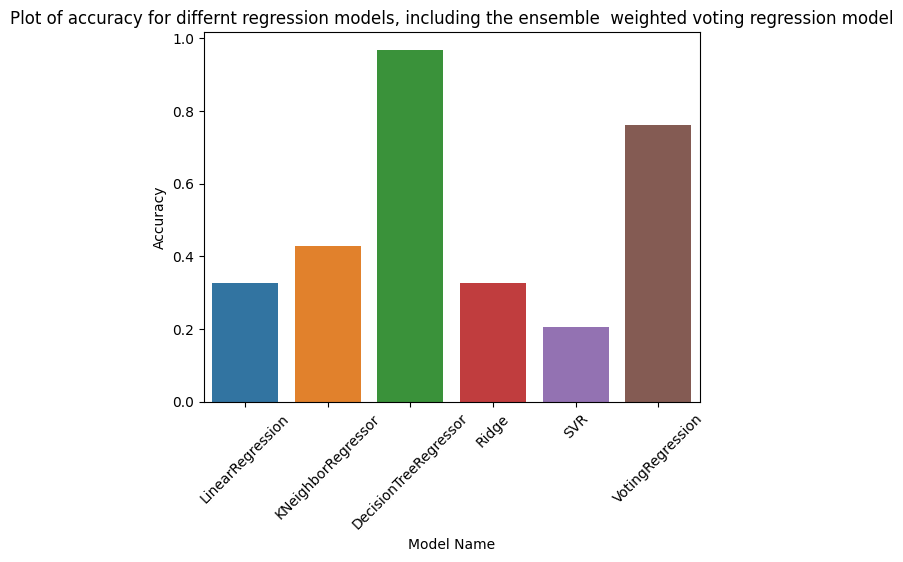

In [31]:
# Use the weighted estimators for turning the VotingRegressor
voting_regressor2 = VotingRegressor(estimators=estimators, weights=[0.1, 0.2, 0.4, 0.2, 0.1])
all_regressors2 = estimators + [('VotingRegression', voting_regressor2)]
acc_df2 = fit_all_regressors(all_regressors2)
plot_model_accuracy(acc_df2, ' weighted ')

